In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
import sys
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.utils.config import TICKERS, PROCESSED_DIR, RAW_DIR
# Set consistent plot style for all charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
COLORS = sns.color_palette('husl', 10)
# Create docs folder for saving charts
import os
os.makedirs('../../docs/eda', exist_ok=True)
print('Setup complete!')

Setup complete!


In [2]:
# Loading all 10 cleaned tickers into one dict
price_data = {}
for ticker in TICKERS:
    fp = PROCESSED_DIR / f'features/{ticker}_clean.csv'
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    price_data[ticker] = df
print(f'Loaded {len(price_data)} tickers')
print(f'Date range: {list(price_data.values())[0].index.min()} '
      f'to {list(price_data.values())[0].index.max()}')
print(f'Columns: {list(list(price_data.values())[0].columns)}')

Loaded 10 tickers
Date range: 2015-01-05 00:00:00 to 2025-12-30 00:00:00
Columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Daily_Return', 'Log_Return', 'Price_Range', 'Gap']


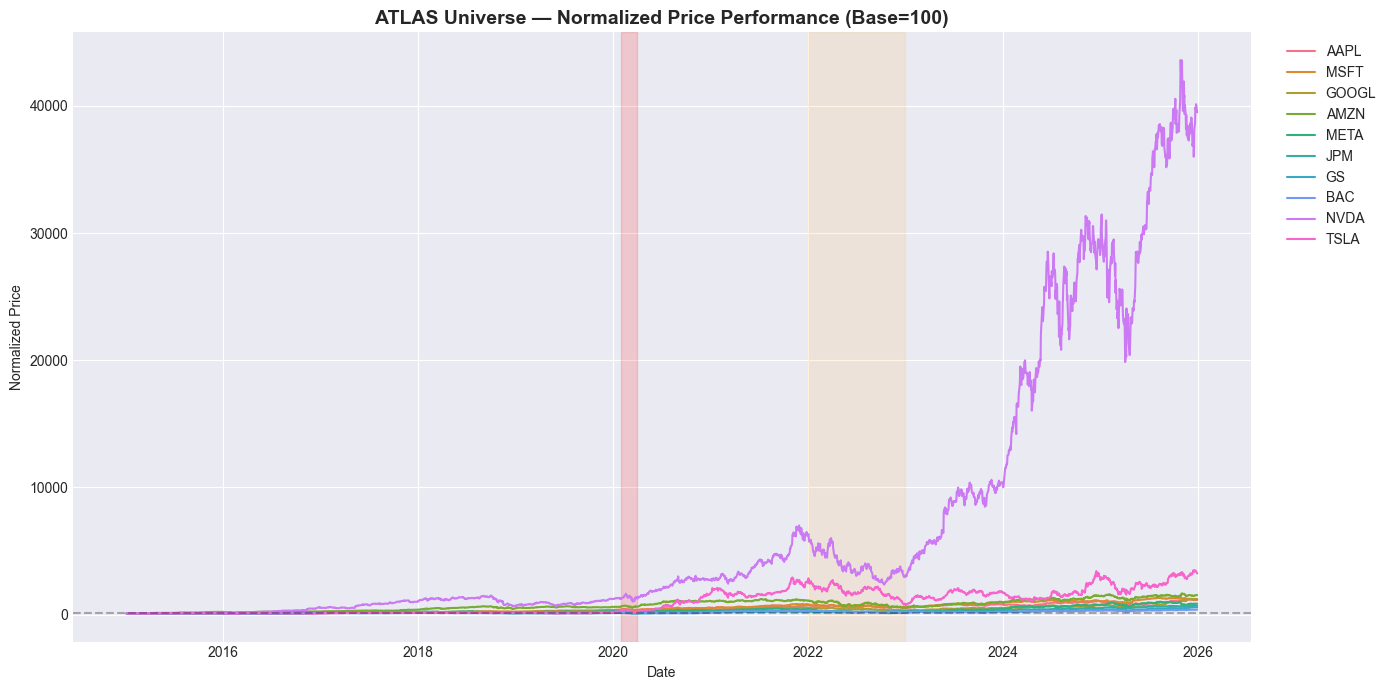

Chart 1 saved!


In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
for i, (ticker, df) in enumerate(price_data.items()):
    # Normalize: start at 100
    normalized = df['Close'] / df['Close'].iloc[0] * 100
    ax.plot(normalized.index, normalized.values,
            label=ticker, color=COLORS[i], linewidth=1.5)
ax.set_title('ATLAS Universe — Normalized Price Performance (Base=100)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Price')
ax.set_xlabel('Date')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(100, color='black', linestyle='--', alpha=0.3)
# Annotate major market events
ax.axvspan('2020-02-01', '2020-04-01', alpha=0.15, color='red',
           label='COVID Crash')
ax.axvspan('2022-01-01', '2022-12-31', alpha=0.1, color='orange',
           label='2022 Bear Market')
plt.tight_layout()
plt.savefig('../../docs/eda/01_normalized_prices.png', dpi=150)
plt.show()
print('Chart 1 saved!')

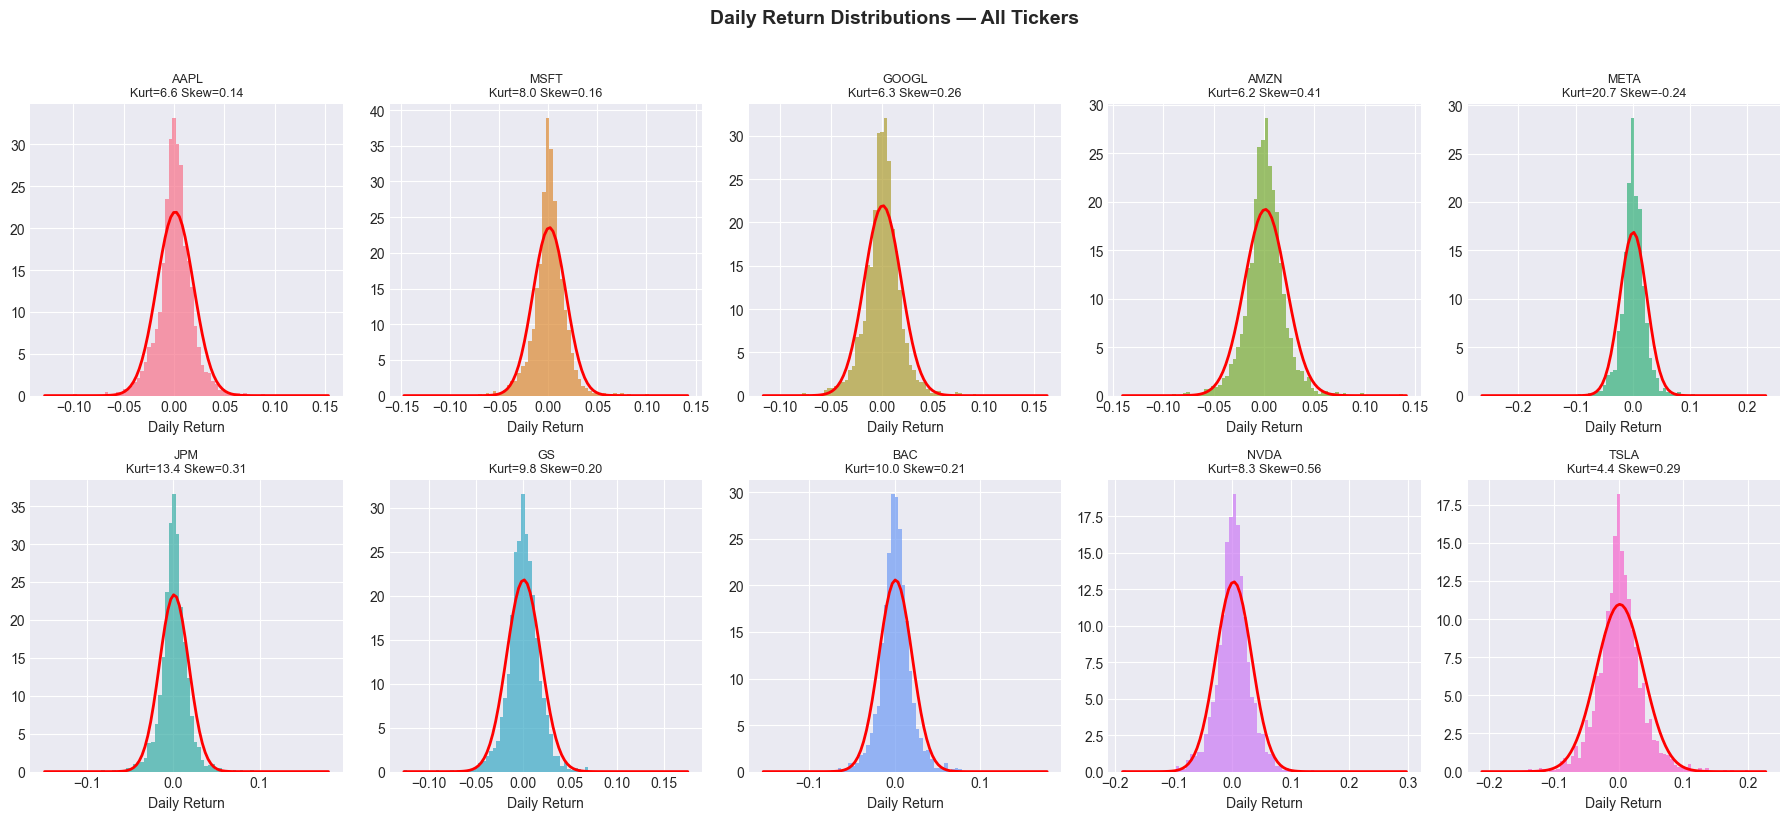


Return Statistics Summary:
         Mean    Std  Kurtosis  Skewness     Min     Max
Ticker                                                  
AAPL    0.104  1.817     6.582     0.140 -12.865  15.329
MSFT    0.105  1.694     7.962     0.157 -14.739  14.217
GOOGL   0.106  1.817     6.320     0.255 -11.634  16.258
AMZN    0.120  2.075     6.187     0.414 -14.049  14.131
META    0.106  2.365    20.671    -0.242 -26.390  23.282
JPM     0.085  1.711    13.447     0.308 -14.965  18.012
GS      0.079  1.831     9.771     0.204 -12.705  17.580
BAC     0.068  1.937     9.981     0.207 -15.397  17.796
NVDA    0.263  3.068     8.271     0.558 -18.756  29.807
TSLA    0.190  3.639     4.446     0.289 -21.063  22.690


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
stats_summary = []
for i, (ticker, df) in enumerate(price_data.items()):
    returns = df['Daily_Return'].dropna()
    # Plot histogram with normal distribution overlay
    axes[i].hist(returns, bins=80, density=True,
                 alpha=0.7, color=COLORS[i], edgecolor='none')
    # Fit and plot normal distribution
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma),
                 'r-', linewidth=2, label='Normal')
    # Calculate statistics
    kurt  = returns.kurtosis()
    skew  = returns.skew()
    axes[i].set_title(f'{ticker}\nKurt={kurt:.1f} Skew={skew:.2f}',
                      fontsize=9)
    axes[i].set_xlabel('Daily Return')
    stats_summary.append({
        'Ticker': ticker, 'Mean': mu*100, 'Std': sigma*100,
        'Kurtosis': kurt, 'Skewness': skew,
        'Min': returns.min()*100, 'Max': returns.max()*100
    })
plt.suptitle('Daily Return Distributions — All Tickers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../../docs/eda/02_return_distributions.png', dpi=150)
plt.show()
# Print statistics table
stats_df = pd.DataFrame(stats_summary).set_index('Ticker')
print('\nReturn Statistics Summary:')
print(stats_df.round(3).to_string())  

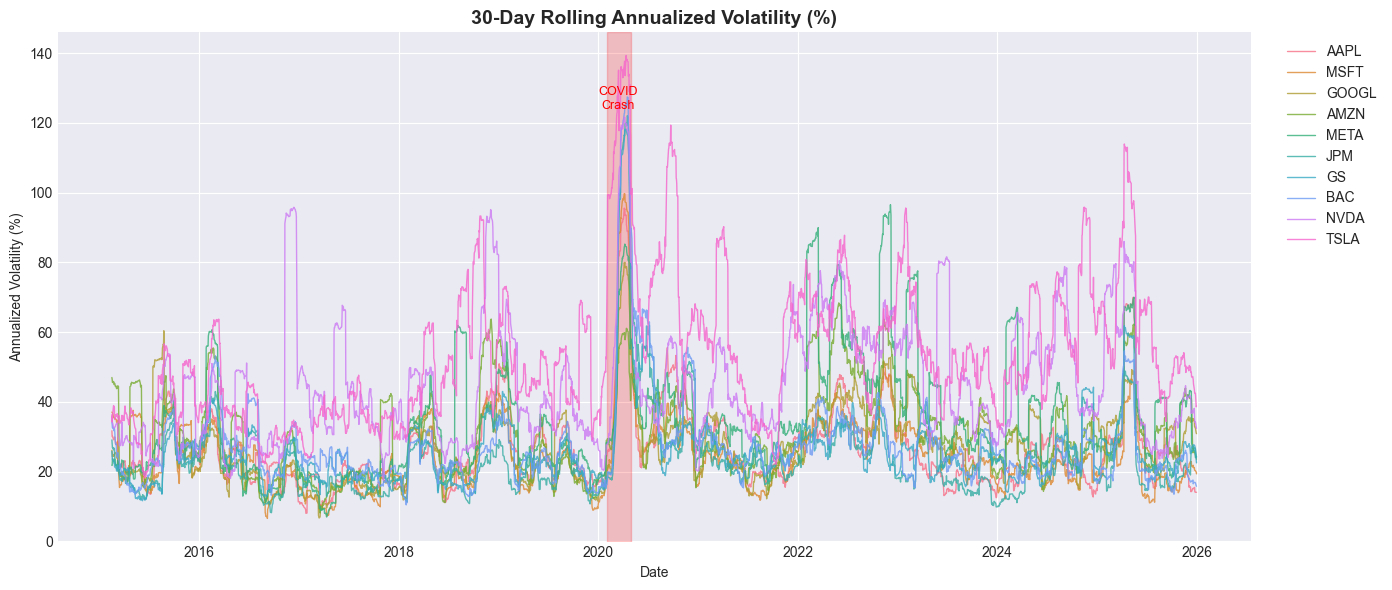

In [9]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 6))

for i, (ticker, df) in enumerate(price_data.items()):
    vol = df['Daily_Return'].rolling(30).std() * np.sqrt(252) * 100
    ax.plot(vol.index, vol.values,
            label=ticker, color=COLORS[i], linewidth=1, alpha=0.8)

ax.set_title('30-Day Rolling Annualized Volatility (%)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)')
ax.set_xlabel('Date')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Fix: use pd.Timestamp instead of date strings
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-30'),
           alpha=0.2, color='red')

# Fix: annotate with numeric x position
ax.annotate('COVID\nCrash',
            xy=(pd.Timestamp('2020-03-15'), ax.get_ylim()[1] * 0.85),
            fontsize=9, ha='center', color='red',
            xycoords=('data', 'data'))

plt.tight_layout()
plt.savefig('../../docs/eda/03_rolling_volatility.png', dpi=150)
plt.show()

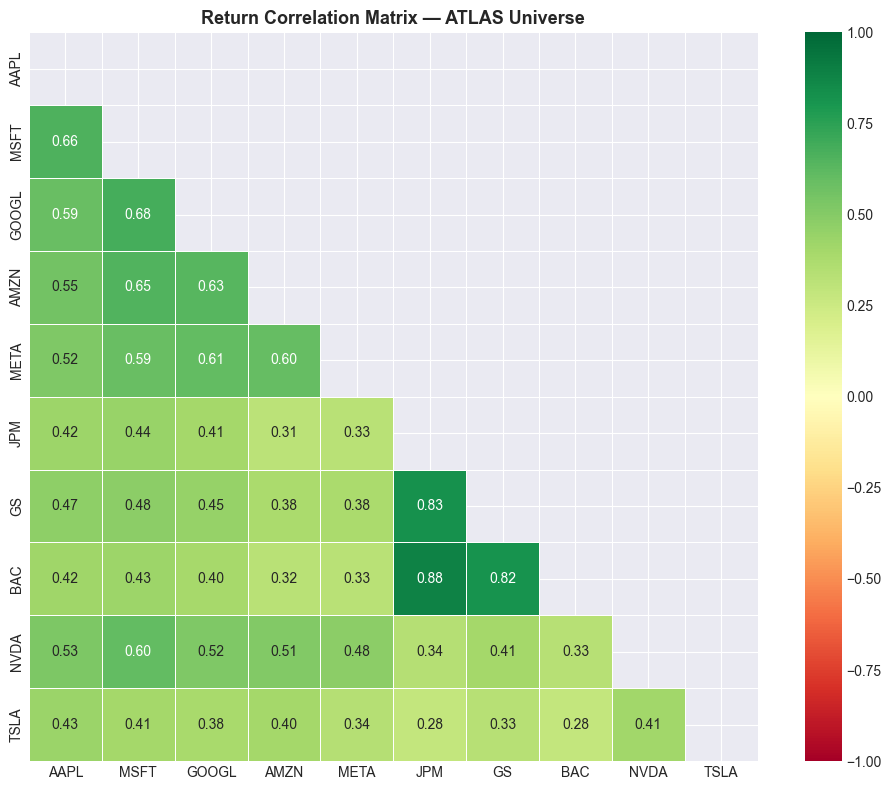


Top 5 most correlated pairs:
          Pair  Correlation
36     JPM-BAC     0.884609
35      JPM-GS     0.826742
39      GS-BAC     0.818307
9   MSFT-GOOGL     0.684288
0    AAPL-MSFT     0.663191

Top 5 least correlated pairs:
        Pair  Correlation
30  META-JPM     0.327550
27  AMZN-BAC     0.320337
25  AMZN-JPM     0.313913
38  JPM-TSLA     0.284510
43  BAC-TSLA     0.284180


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Build returns matrix
returns_matrix = pd.DataFrame({
    ticker: df['Daily_Return']
    for ticker, df in price_data.items()
})

# Compute correlation matrix
corr_matrix = returns_matrix.corr()

# Visualize with a Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Mask the upper triangle to show only the unique relationships
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, 
    vmax=1,
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5
)

ax.set_title('Return Correlation Matrix — ATLAS Universe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/eda/04_ticker_correlation.png', dpi=150)
plt.show()

# Print highest correlations
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_pairs.append({
            'Pair': f"{corr_matrix.columns[i]}-{corr_matrix.columns[j]}",
            'Correlation': corr_matrix.iloc[i, j]
        })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)

print('\nTop 5 most correlated pairs:')
print(corr_pairs_df.head())

print('\nTop 5 least correlated pairs:')
print(corr_pairs_df.tail())